Libraries

In [48]:
import os
import json
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import seaborn as sns
import warnings

Paths

In [49]:
QUERIES_DIR = "data/results/queries"
MODELS_DIR = "data/results/models"

# Join Results

## Queries

In [50]:
queries_rows = []

for file_name in os.listdir(QUERIES_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(QUERIES_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for metric in run.get("metrics", []):

                row = {
                    **base_info,

                    "query_description": metric.get("Query Description"),
                    "api_time_s": metric.get("API Time (s)"),
                    "sql_time_s": metric.get("SQL Time (s)"),
                    "time_delta": metric.get("Time Delta (SQL - API)")
                }

                queries_rows.append(row)

df_queries = pd.DataFrame(queries_rows)

## Models

In [51]:
models_rows = []

for file_name in os.listdir(MODELS_DIR):

    if file_name.endswith(".json"):

        file_path = os.path.join(MODELS_DIR, file_name)

        with open(file_path, "r") as f:
            data = json.load(f)

        for run in data.get("runs", []):

            base_info = {
                "timestamp": run.get("timestamp"),
                "spark_mode": run.get("spark_mode"),

                "executor_instances": run.get("spark_config", {}).get("executor_instances"),
                "executor_cores": run.get("spark_config", {}).get("executor_cores"),
                "executor_memory": run.get("spark_config", {}).get("executor_memory"),
                "shuffle_partitions": run.get("spark_config", {}).get("shuffle_partitions"),
                "adaptive": run.get("spark_config", {}).get("adaptive")
            }

            for result in run.get("model_results", []):

                metrics = result.get("metrics", {})

                row = {
                    **base_info,

                    "model_name": result.get("model_name"),
                    "target": result.get("target"),
                    "task_type": result.get("task_type"),

                    "rmse": metrics.get("rmse"),
                    "r2": metrics.get("r2"),
                    "mae": metrics.get("mae"),
                    "mse": metrics.get("mse"),

                    "execution_time_seconds": result.get("execution_time_seconds")
                }

                models_rows.append(row)

df_models = pd.DataFrame(models_rows)

## Preview

In [52]:
print("\n==============================")
print("QUERIES DATAFRAME")
print("==============================")
print(df_queries.head())

print("\nShape:", df_queries.shape)

print("\n==============================")
print("MODELS DATAFRAME")
print("==============================")
print(df_models.head())

print("\nShape:", df_models.shape)


QUERIES DATAFRAME
             timestamp spark_mode  executor_instances  executor_cores  \
0  2026-05-18 22:31:06   baseline                   2               1   
1  2026-05-18 22:31:06   baseline                   2               1   
2  2026-05-18 22:31:06   baseline                   2               1   
3  2026-05-18 22:31:06   baseline                   2               1   
4  2026-05-18 22:31:06   baseline                   2               1   

  executor_memory  shuffle_partitions  adaptive  \
0              3g                  50     False   
1              3g                  50     False   
2              3g                  50     False   
3              3g                  50     False   
4              3g                  50     False   

                         query_description  api_time_s  sql_time_s  time_delta  
0  Q1.1: Borough Revenue vs Tip Percentage      9.1348      6.9593     -2.1755  
1            Q1.2: Tip Paradox by Distance      6.5489      6.4698     -0

In [53]:
df_queries

,timestamp,spark_mode,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,query_description,api_time_s,sql_time_s,time_delta
0,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.1: Borough Revenue vs Tip Percentage,9.1348,6.9593,-2.1755
1,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.2: Tip Paradox by Distance,6.5489,6.4698,-0.0791
2,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.3: Revenue Composition,1.8494,1.3900,-0.4594
3,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.4: Payment Method Impact,5.6741,5.2889,-0.3852
4,2026-05-18 22:31:06,baseline,2,1,3g,50,False,Q1.5: Passenger Count Impact,6.0691,5.7165,-0.3525
...,...,...,...,...,...,...,...,...,...,...,...
894,2026-05-19 17:03:52,cpu_heavy,3,3,3g,150,True,Q4.9: Monthly Evolution of Average Revenue by ...,5.0501,4.1484,-0.9017
895,2026-05-19 17:03:52,cpu_heavy,3,3,3g,150,True,Q5.1: Hourly Analysis of Taxi Operations,5.4707,4.9974,-0.4733
896,2026-05-19 17:03:52,cpu_heavy,3,3,3g,150,True,Q5.2: Analysis of Non-Revenue Trips and Disput...,4.1341,4.1788,0.0448
897,2026-05-19 17:03:52,cpu_heavy,3,3,3g,150,True,Q5.3: The Inverse Relationship Between Revenue...,4.3316,4.5044,0.1728


---

# **Derived Features & Plot Styling**

We extend the two DataFrames with a few derived columns useful across the analysis:
- `total_cores` = `executor_instances` × `executor_cores` (cluster-wide parallelism)
- `faster_engine` for queries (API or SQL)
- `time_per_core` (a rough measure of work density)

We also fix a consistent color palette so the same scenario is always the same color in every figure.

In [54]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.labelsize": 10, "legend.fontsize": 9,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
})

# Canonical scenario order — same color for the same scenario everywhere
SCENARIO_ORDER = [
    "baseline", "balanced", "high_parallelism", "memory_optimized",
    "stress_test", "low_overhead", "aqe_only", "cpu_heavy"
]
SCENARIO_PALETTE = dict(zip(SCENARIO_ORDER, sns.color_palette("tab10", n_colors=8)))

# Derived features for queries
df_queries["total_cores"] = df_queries["executor_instances"] * df_queries["executor_cores"]
df_queries["faster_engine"] = np.where(df_queries["sql_time_s"] < df_queries["api_time_s"], "SQL", "API")
df_queries["api_speedup_over_sql"] = df_queries["sql_time_s"] / df_queries["api_time_s"]

# Derived features for models
df_models["total_cores"] = df_models["executor_instances"] * df_models["executor_cores"]
df_models["time_per_core_s"] = df_models["execution_time_seconds"] / df_models["total_cores"]

# Filter to only scenarios actually present in our results
present_scenarios = [s for s in SCENARIO_ORDER if s in df_queries["spark_mode"].unique()]
present_scenarios_models = [s for s in SCENARIO_ORDER if s in df_models["spark_mode"].unique()]

# Model palette — fill in once we know which models we have
unique_models = sorted(df_models["model_name"].dropna().unique())
MODEL_PALETTE = dict(zip(unique_models, sns.color_palette("Set2", n_colors=len(unique_models))))

print(f"Queries scenarios:  {present_scenarios}")
print(f"Models scenarios:   {present_scenarios_models}")
print(f"Models found:       {unique_models}")
print(f"Targets:            {sorted(df_models['target'].dropna().unique())}")


Queries scenarios:  ['baseline', 'balanced', 'high_parallelism', 'memory_optimized', 'stress_test', 'low_overhead', 'aqe_only', 'cpu_heavy']
Models scenarios:   ['baseline', 'balanced', 'high_parallelism', 'memory_optimized', 'stress_test', 'low_overhead', 'aqe_only', 'cpu_heavy']
Models found:       ['DecisionTreeRegressor', 'GBTRegressor', 'GeneralizedLinearModel', 'LinearRegression_Ridge_Std', 'RandomForestRegressor']
Targets:            ['total_amount', 'trip_duration_min']


## **Coverage Sanity Check**

Before drawing any conclusions, we verify how many runs we have per (scenario × workload). Empty cells mean a particular scenario was never successfully executed (typically because of YARN allocation limits — e.g. `cpu_heavy` requesting `executor_cores=3` exceeds the maximum of 2 on `n2-standard-2` workers).

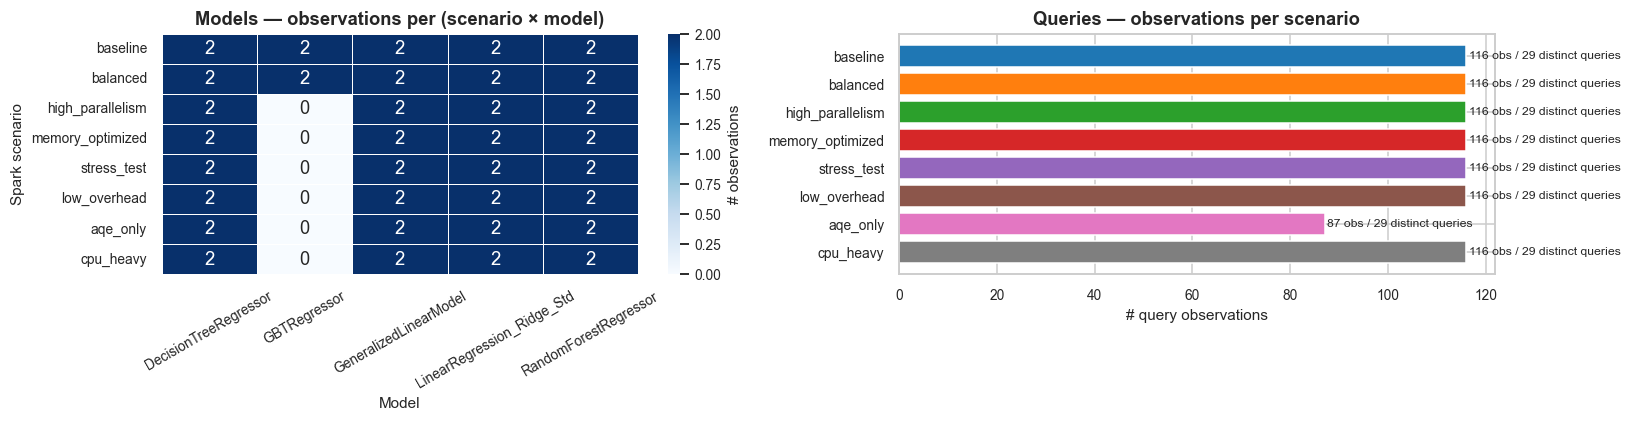

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Queries: rows per (scenario, query)
q_coverage = (df_queries.groupby(["spark_mode", "query_description"])
                        .size().unstack(fill_value=0)
                        .reindex(present_scenarios))
# Show only the count totals to keep it readable
q_totals = q_coverage.sum(axis=1).to_frame("runs_per_scenario")
q_totals["distinct_queries"] = (q_coverage > 0).sum(axis=1)

# Models: rows per (scenario, model)
m_coverage = (df_models.groupby(["spark_mode", "model_name"])
                       .size().unstack(fill_value=0)
                       .reindex(present_scenarios_models))

sns.heatmap(m_coverage, annot=True, fmt="d", cmap="Blues",
            cbar_kws={"label": "# observations"}, ax=axes[0],
            linewidths=0.5, linecolor="white")
axes[0].set_title("Models — observations per (scenario × model)")
axes[0].set_xlabel("Model"); axes[0].set_ylabel("Spark scenario")
axes[0].tick_params(axis="x", rotation=30)

# For queries: show total runs and distinct queries per scenario
axes[1].barh(q_totals.index, q_totals["runs_per_scenario"],
             color=[SCENARIO_PALETTE[s] for s in q_totals.index],
             edgecolor="white")
for i, (total, distinct) in enumerate(zip(q_totals["runs_per_scenario"], q_totals["distinct_queries"])):
    axes[1].text(total + 0.5, i, f"{int(total)} obs / {int(distinct)} distinct queries",
                 va="center", fontsize=8)
axes[1].set_title("Queries — observations per scenario")
axes[1].set_xlabel("# query observations")
axes[1].invert_yaxis()

plt.tight_layout(); plt.show()


---

# **1. Scenario Profiling**

Characterizing the 8 Spark configurations *before* looking at performance. Each scenario tests a specific hypothesis about Spark tuning:

| Scenario | Configuration intent |
|---|---|
| `baseline` | Conservative reference — minimal resources, AQE off |
| `balanced` | Moderate parallelism, AQE on |
| `high_parallelism` | More executors and shuffle partitions |
| `memory_optimized` | Trade cores for memory per executor |
| `stress_test` | Many small executors, aggressive shuffle |
| `low_overhead` | Few large partitions, AQE off — minimize scheduling cost |
| `aqe_only` | Same as baseline but AQE on — isolates AQE's effect |
| `cpu_heavy` | More cores per executor (limited by YARN max-allocation) |

In [56]:
scenario_cfg = (
    df_queries.dropna(subset=["spark_mode"])
              .groupby("spark_mode")
              .agg(executor_instances=("executor_instances", "first"),
                   executor_cores=("executor_cores", "first"),
                   executor_memory=("executor_memory", "first"),
                   shuffle_partitions=("shuffle_partitions", "first"),
                   adaptive=("adaptive", "first"),
                   total_cores=("total_cores", "first"))
              .reindex(present_scenarios)
)
scenario_cfg

,executor_instances,executor_cores,executor_memory,shuffle_partitions,adaptive,total_cores
spark_mode,,,,,,
baseline,2,1,3g,50,False,2
balanced,2,2,4g,100,True,4
high_parallelism,3,2,4g,150,True,6
memory_optimized,2,1,6g,100,True,2
stress_test,4,2,3g,200,True,8
low_overhead,2,2,4g,25,False,4
aqe_only,2,1,3g,50,True,2
cpu_heavy,3,3,3g,150,True,9


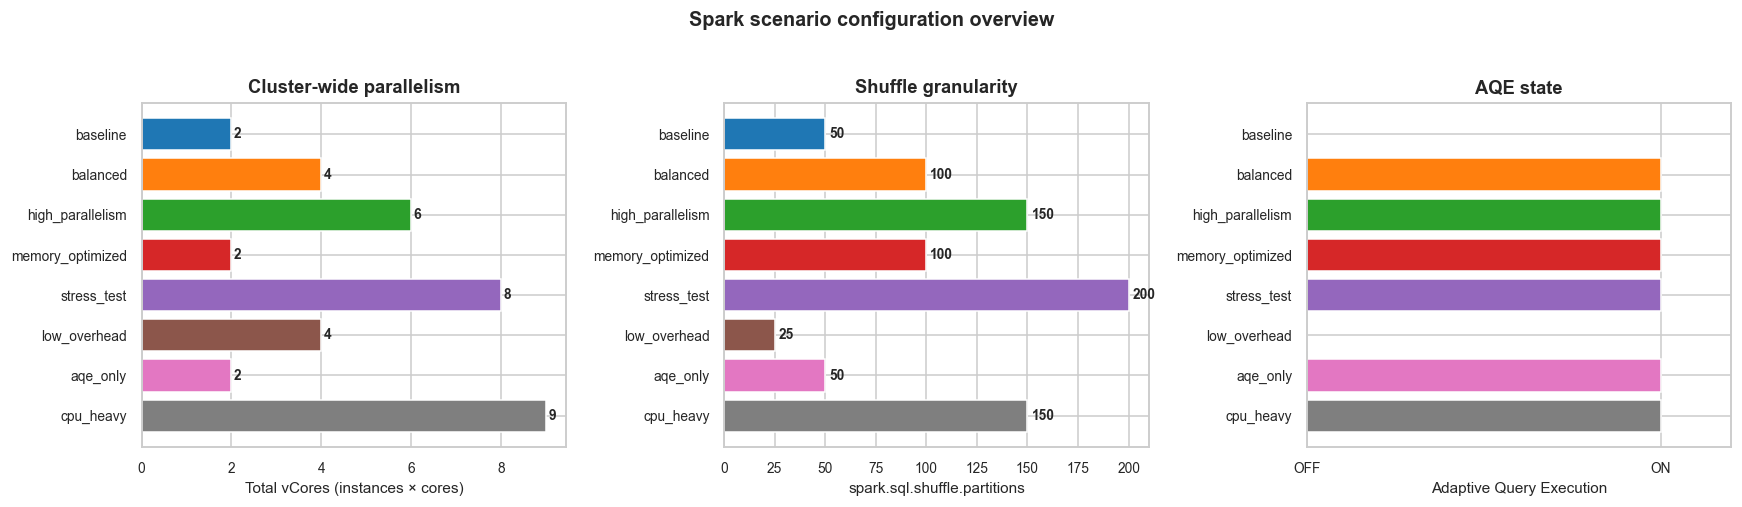

In [57]:
# Visualize the configuration space along its main axes
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
scenarios = scenario_cfg.index.tolist()
colors = [SCENARIO_PALETTE[s] for s in scenarios]

axes[0].barh(scenarios, scenario_cfg["total_cores"], color=colors, edgecolor="white")
axes[0].set_xlabel("Total vCores (instances × cores)")
axes[0].set_title("Cluster-wide parallelism")
axes[0].invert_yaxis()
for i, v in enumerate(scenario_cfg["total_cores"]):
    axes[0].text(v + 0.05, i, str(int(v)), va="center", fontsize=9, fontweight="bold")

axes[1].barh(scenarios, scenario_cfg["shuffle_partitions"], color=colors, edgecolor="white")
axes[1].set_xlabel("spark.sql.shuffle.partitions")
axes[1].set_title("Shuffle granularity")
axes[1].invert_yaxis()
for i, v in enumerate(scenario_cfg["shuffle_partitions"]):
    axes[1].text(v + 2, i, str(int(v)), va="center", fontsize=9, fontweight="bold")

aqe_int = scenario_cfg["adaptive"].astype(int)
axes[2].barh(scenarios, aqe_int, color=colors, edgecolor="white")
axes[2].set_xlim(0, 1.2)
axes[2].set_xticks([0, 1]); axes[2].set_xticklabels(["OFF", "ON"])
axes[2].set_xlabel("Adaptive Query Execution")
axes[2].set_title("AQE state")
axes[2].invert_yaxis()

plt.suptitle("Spark scenario configuration overview", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


### **1.1. Configuration similarity — clustering scenarios**

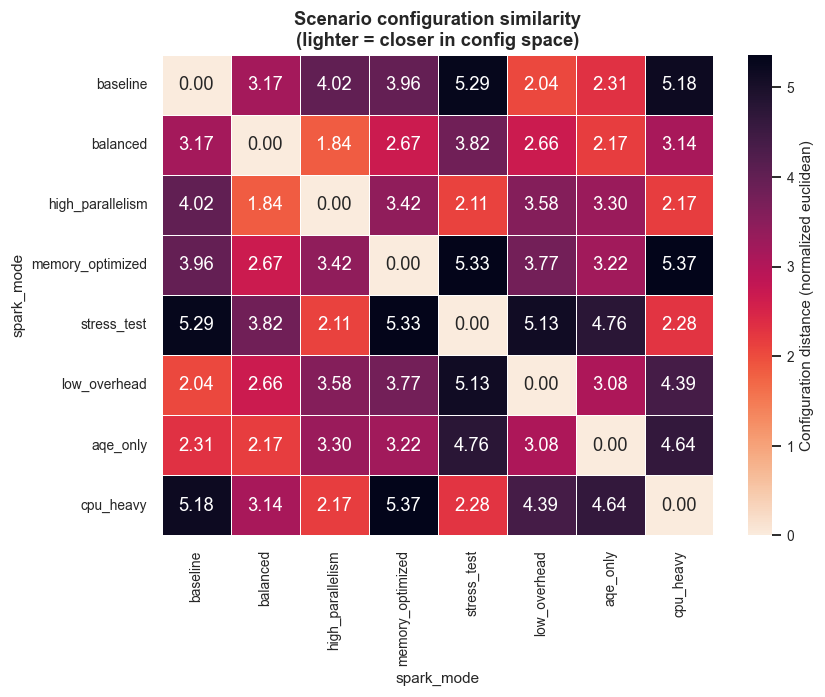


Closest pair: balanced ↔ high_parallelism (distance = 1.838)
Most distinct pair: memory_optimized ↔ cpu_heavy (distance = 5.367)


In [58]:
from scipy.spatial.distance import pdist, squareform

# Build a numeric feature matrix from the configuration
config_features = scenario_cfg.copy()
config_features["adaptive"] = config_features["adaptive"].astype(int)
config_features["memory_gb"] = (
    config_features["executor_memory"]
    .str.replace("g", "", regex=False).astype(float)
)

feature_cols = ["executor_instances", "executor_cores", "memory_gb",
                "shuffle_partitions", "adaptive", "total_cores"]

# Z-score normalize so each feature contributes equally
X = config_features[feature_cols].values.astype(float)
X_norm = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-9)

dist_matrix = squareform(pdist(X_norm, metric="euclidean"))
dist_df = pd.DataFrame(dist_matrix, index=config_features.index, columns=config_features.index)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(dist_df, annot=True, fmt=".2f", cmap="rocket_r",
            cbar_kws={"label": "Configuration distance (normalized euclidean)"},
            linewidths=0.5, linecolor="white", ax=ax)
ax.set_title("Scenario configuration similarity\n(lighter = closer in config space)")
plt.tight_layout(); plt.show()

# Find the closest pair (excluding self-distance) and the most distinct
np.fill_diagonal(dist_matrix, np.inf)
i, j = np.unravel_index(dist_matrix.argmin(), dist_matrix.shape)
print(f"\nClosest pair: {config_features.index[i]} ↔ {config_features.index[j]} "
      f"(distance = {dist_matrix[i, j]:.3f})")

np.fill_diagonal(dist_matrix, -np.inf)
i, j = np.unravel_index(dist_matrix.argmax(), dist_matrix.shape)
print(f"Most distinct pair: {config_features.index[i]} ↔ {config_features.index[j]} "
      f"(distance = {dist_matrix[i, j]:.3f})")


---

# **2. Spark Performance — Analytical Queries**

For each scenario we measure execution time using two engines:
- **API** — DataFrame API (lazy-evaluated, Python)
- **SQL** — Spark SQL string queries

## **2.1. Total workload time per scenario**

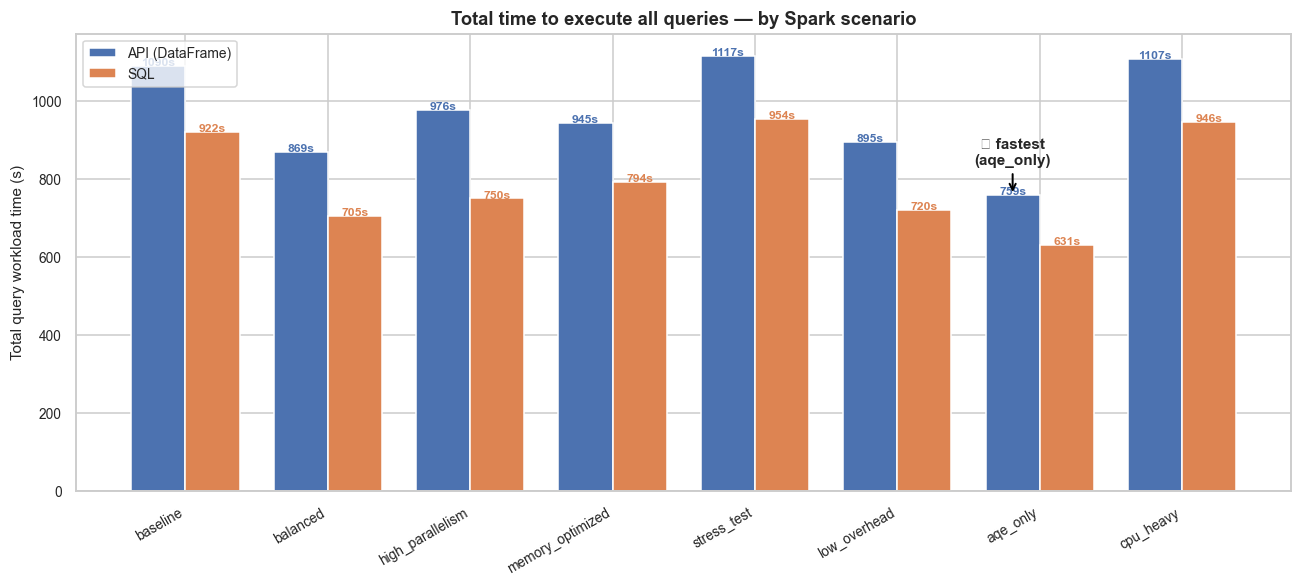


Numerical summary:
                  api_total  sql_total  api_mean  sql_mean  api_std  sql_std  \
spark_mode                                                                     
baseline            1089.82     922.23      9.39      7.95    14.81    11.86   
balanced             869.05     704.72      7.49      6.08    15.26    12.55   
high_parallelism     976.18     750.49      8.42      6.47    15.47    11.91   
memory_optimized     944.93     793.60      8.15      6.84    14.36    11.08   
stress_test         1116.95     953.83      9.63      8.22    15.53    12.20   
low_overhead         895.41     720.15      7.72      6.21    16.96    14.51   
aqe_only             759.01     630.92      8.72      7.25    14.83    11.43   
cpu_heavy           1107.01     945.91      9.54      8.15    15.48    12.30   

                  n_queries  
spark_mode                   
baseline                116  
balanced                116  
high_parallelism        116  
memory_optimized        116  

In [ ]:
# Aggregate: total time of all queries combined within each scenario
totals = (
    df_queries.groupby("spark_mode")
              .agg(api_total=("api_time_s", "sum"),
                   sql_total=("sql_time_s", "sum"),
                   api_mean=("api_time_s", "mean"),
                   sql_mean=("sql_time_s", "mean"),
                   api_std=("api_time_s", "std"),
                   sql_std=("sql_time_s", "std"),
                   n_queries=("query_description", "count"))
              .reindex(present_scenarios)
)

fig, ax = plt.subplots(figsize=(12, 5.5))
x = np.arange(len(totals)); w = 0.38

bars1 = ax.bar(x - w/2, totals["api_total"], w,
               label="API (DataFrame)", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + w/2, totals["sql_total"], w,
               label="SQL", color="#DD8452", edgecolor="white")

ax.set_xticks(x); ax.set_xticklabels(totals.index, rotation=30, ha="right")
ax.set_ylabel("Total query workload time (s)")
ax.set_title("Total time to execute all queries — by Spark scenario")
ax.legend(loc="upper left")

# Numerical annotations
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.0f}s", ha="center", fontsize=8, color="#4C72B0", fontweight="bold")
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f"{bar.get_height():.0f}s", ha="center", fontsize=8, color="#DD8452", fontweight="bold")

# Highlight the fastest scenario
best = totals["api_total"].idxmin()
best_pos = list(totals.index).index(best)
ax.annotate(f"fastest\n({best})",
            xy=(best_pos - w/2, totals.loc[best, "api_total"]),
            xytext=(best_pos - w/2, totals["api_total"].max() * 0.75),
            ha="center", fontsize=10, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="black", lw=1.3))

plt.tight_layout(); plt.show()
print("\nNumerical summary:")
print(totals.round(2))


## **2.2. API vs SQL — does the engine matter?**

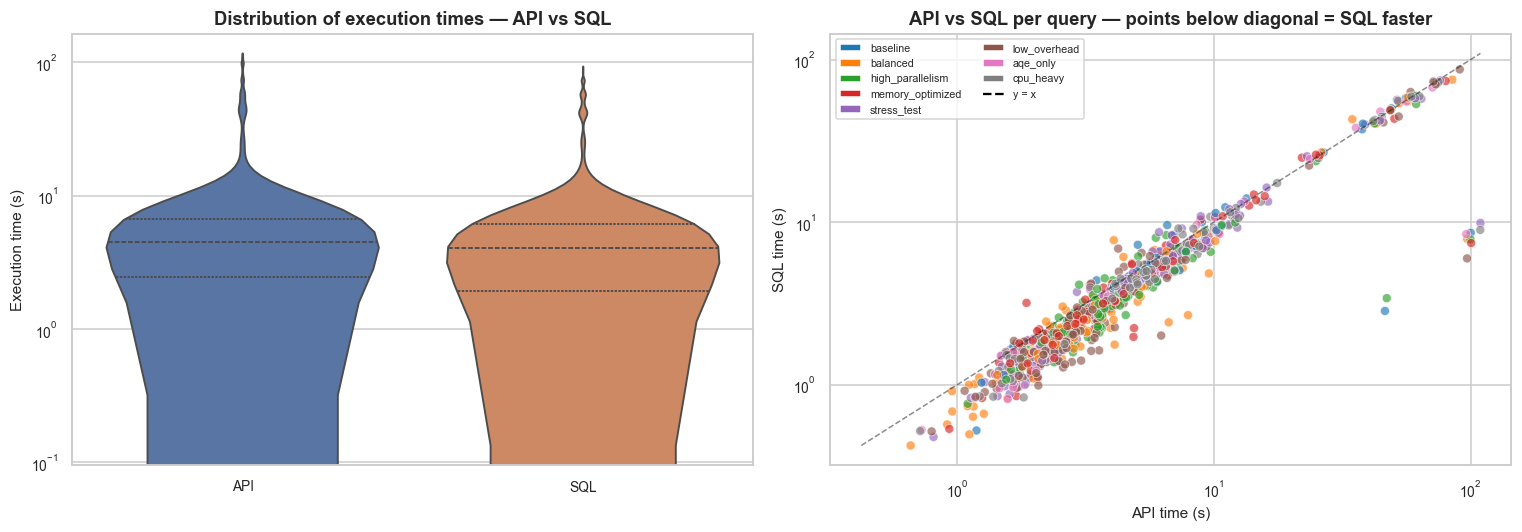


SQL faster than API: 86.7% of (query × scenario) cases
Mean   delta (SQL - API): -1.487s
Median delta (SQL - API): -0.526s


In [60]:
api_sql_long = df_queries.melt(
    id_vars=["spark_mode", "query_description"],
    value_vars=["api_time_s", "sql_time_s"],
    var_name="engine", value_name="time_s"
).assign(engine=lambda d: d["engine"].map({"api_time_s": "API", "sql_time_s": "SQL"}))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Distribution of times by engine
sns.violinplot(data=api_sql_long, x="engine", y="time_s",
               palette=["#4C72B0", "#DD8452"], inner="quartile", ax=axes[0])
axes[0].set_ylabel("Execution time (s)")
axes[0].set_xlabel("")
axes[0].set_title("Distribution of execution times — API vs SQL")
axes[0].set_yscale("log")

# (b) Per-query scatter: API on x, SQL on y, colored by scenario
sc = df_queries.dropna(subset=["api_time_s", "sql_time_s"])
axes[1].scatter(sc["api_time_s"], sc["sql_time_s"],
                c=[SCENARIO_PALETTE.get(s, "#888") for s in sc["spark_mode"]],
                alpha=0.65, s=35, edgecolor="white", linewidth=0.5)
lim_max = max(sc["api_time_s"].max(), sc["sql_time_s"].max())
lim_min = max(min(sc["api_time_s"].min(), sc["sql_time_s"].min()), 0.001)
axes[1].plot([lim_min, lim_max], [lim_min, lim_max],
             "k--", lw=1, alpha=0.5, label="y = x (equal)")
axes[1].set_xlabel("API time (s)")
axes[1].set_ylabel("SQL time (s)")
axes[1].set_title("API vs SQL per query — points below diagonal = SQL faster")
axes[1].set_xscale("log"); axes[1].set_yscale("log")

# Legend with scenario colors
handles = [Patch(facecolor=SCENARIO_PALETTE[s], label=s)
           for s in present_scenarios if s in sc["spark_mode"].unique()]
handles.append(Line2D([0], [0], color="black", linestyle="--", label="y = x"))
axes[1].legend(handles=handles, loc="upper left", fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

faster_sql_pct = (sc["sql_time_s"] < sc["api_time_s"]).mean() * 100
mean_delta = (sc["sql_time_s"] - sc["api_time_s"]).mean()
median_delta = (sc["sql_time_s"] - sc["api_time_s"]).median()
print(f"\nSQL faster than API: {faster_sql_pct:.1f}% of (query × scenario) cases")
print(f"Mean   delta (SQL - API): {mean_delta:+.3f}s")
print(f"Median delta (SQL - API): {median_delta:+.3f}s")


## **2.3. Per-query cost breakdown**

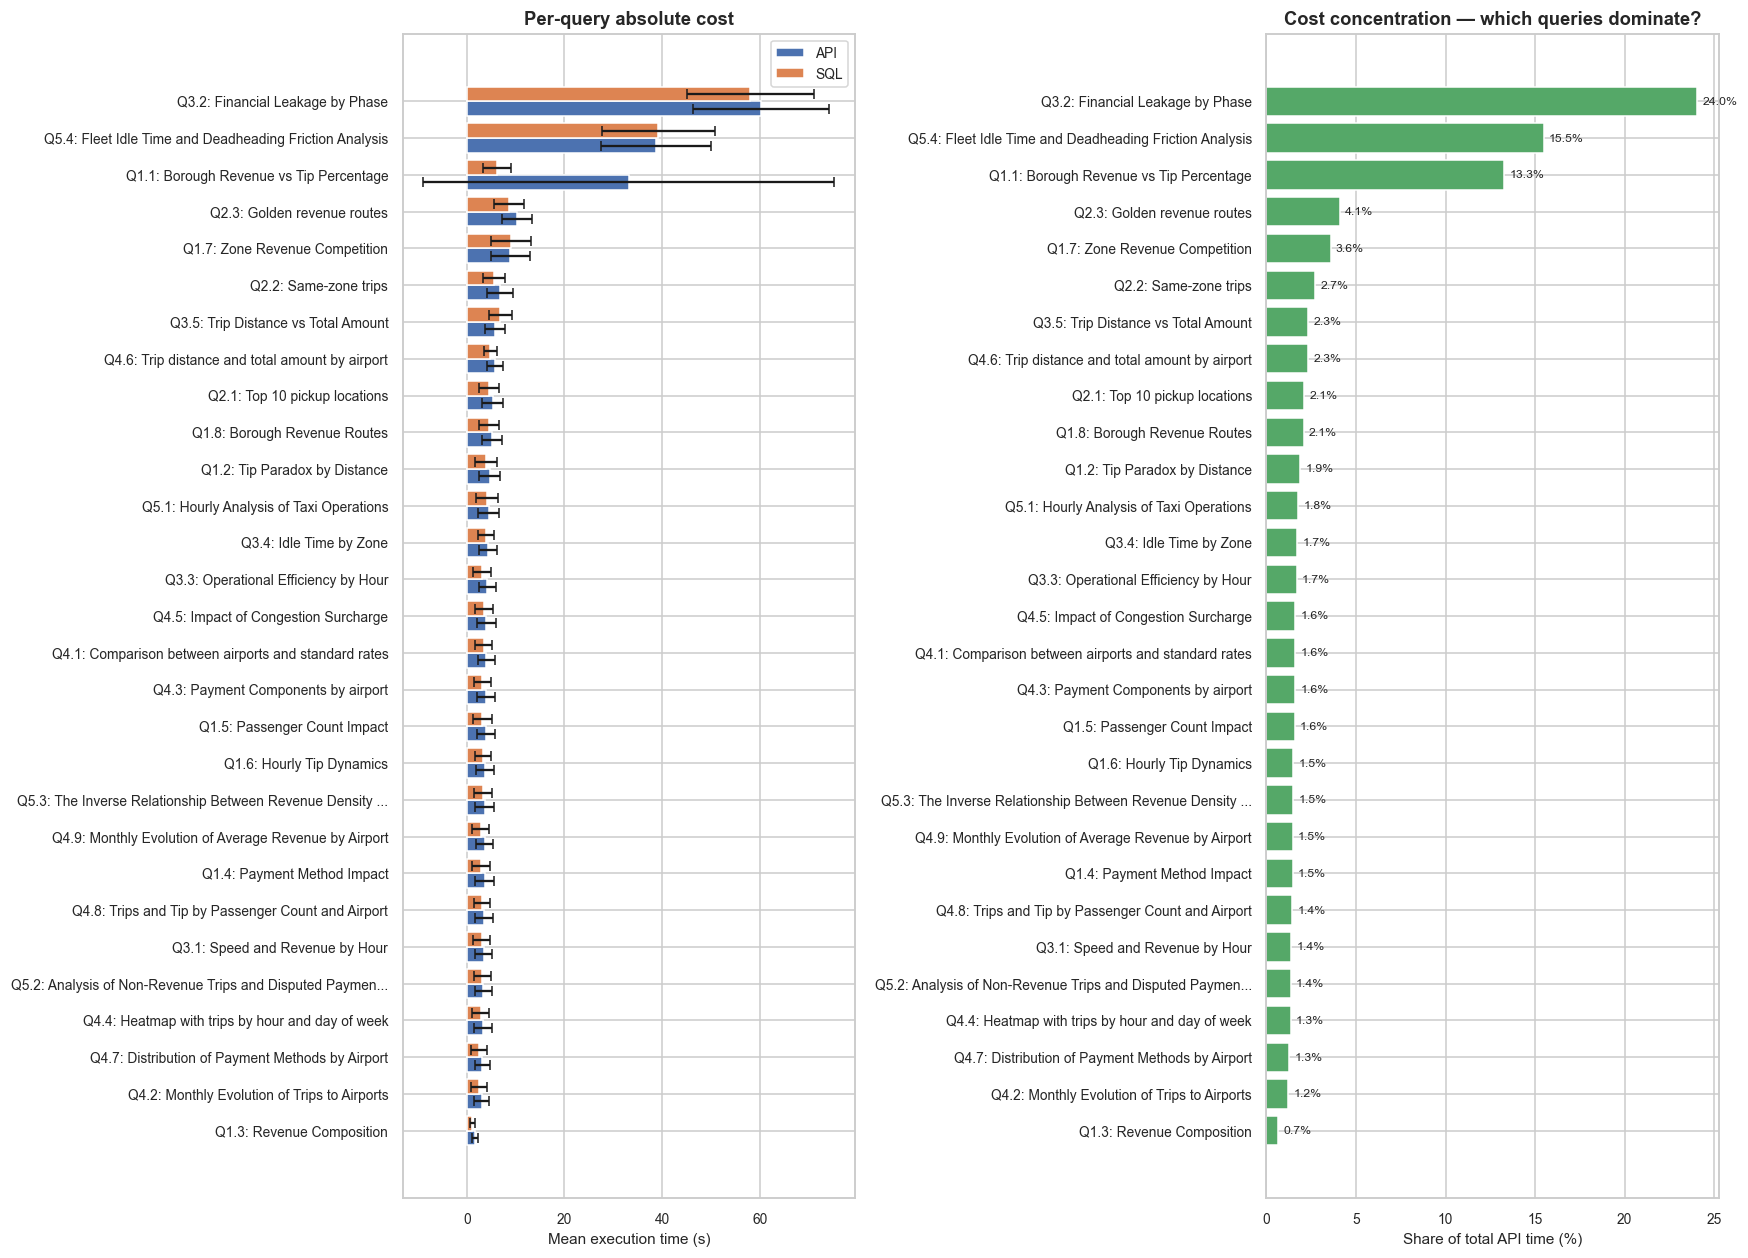


15 of 29 queries account for ~80% of total runtime (Pareto-style concentration).


In [61]:
query_costs = (
    df_queries.groupby("query_description")
              .agg(mean_api=("api_time_s", "mean"),
                   std_api=("api_time_s", "std"),
                   mean_sql=("sql_time_s", "mean"),
                   std_sql=("sql_time_s", "std"),
                   n_obs=("spark_mode", "count"))
              .sort_values("mean_api", ascending=True)
)

# Truncate long descriptions for plot readability
def truncate(s, n=55):
    return (s[:n] + "...") if isinstance(s, str) and len(s) > n else s

query_costs_display = query_costs.copy()
query_costs_display.index = [truncate(d) for d in query_costs_display.index]

# Two side-by-side plots: absolute cost, and cost share
fig, axes = plt.subplots(1, 2, figsize=(16, max(5, 0.4 * len(query_costs))))
y_pos = np.arange(len(query_costs_display)); w = 0.4

axes[0].barh(y_pos - w/2, query_costs_display["mean_api"], w,
             xerr=query_costs_display["std_api"], label="API",
             color="#4C72B0", capsize=3, edgecolor="white")
axes[0].barh(y_pos + w/2, query_costs_display["mean_sql"], w,
             xerr=query_costs_display["std_sql"], label="SQL",
             color="#DD8452", capsize=3, edgecolor="white")
axes[0].set_yticks(y_pos); axes[0].set_yticklabels(query_costs_display.index)
axes[0].set_xlabel("Mean execution time (s)")
axes[0].set_title("Per-query absolute cost")
axes[0].legend()

# Cost share — what fraction of total runtime does each query represent?
total_api = query_costs_display["mean_api"].sum()
share = query_costs_display["mean_api"] / total_api * 100
axes[1].barh(y_pos, share, color="#55A868", edgecolor="white")
axes[1].set_yticks(y_pos); axes[1].set_yticklabels(query_costs_display.index)
axes[1].set_xlabel("Share of total API time (%)")
axes[1].set_title("Cost concentration — which queries dominate?")
for i, v in enumerate(share):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=8)

plt.tight_layout(); plt.show()

# Pareto observation: how many queries account for 80% of the runtime?
cum_share = share.sort_values(ascending=False).cumsum()
n_for_80 = (cum_share <= 80).sum() + 1
print(f"\n{n_for_80} of {len(query_costs)} queries account for ~80% of total runtime "
      f"(Pareto-style concentration).")


## **2.4. Scenario × Query heatmap — where do speedups come from?**

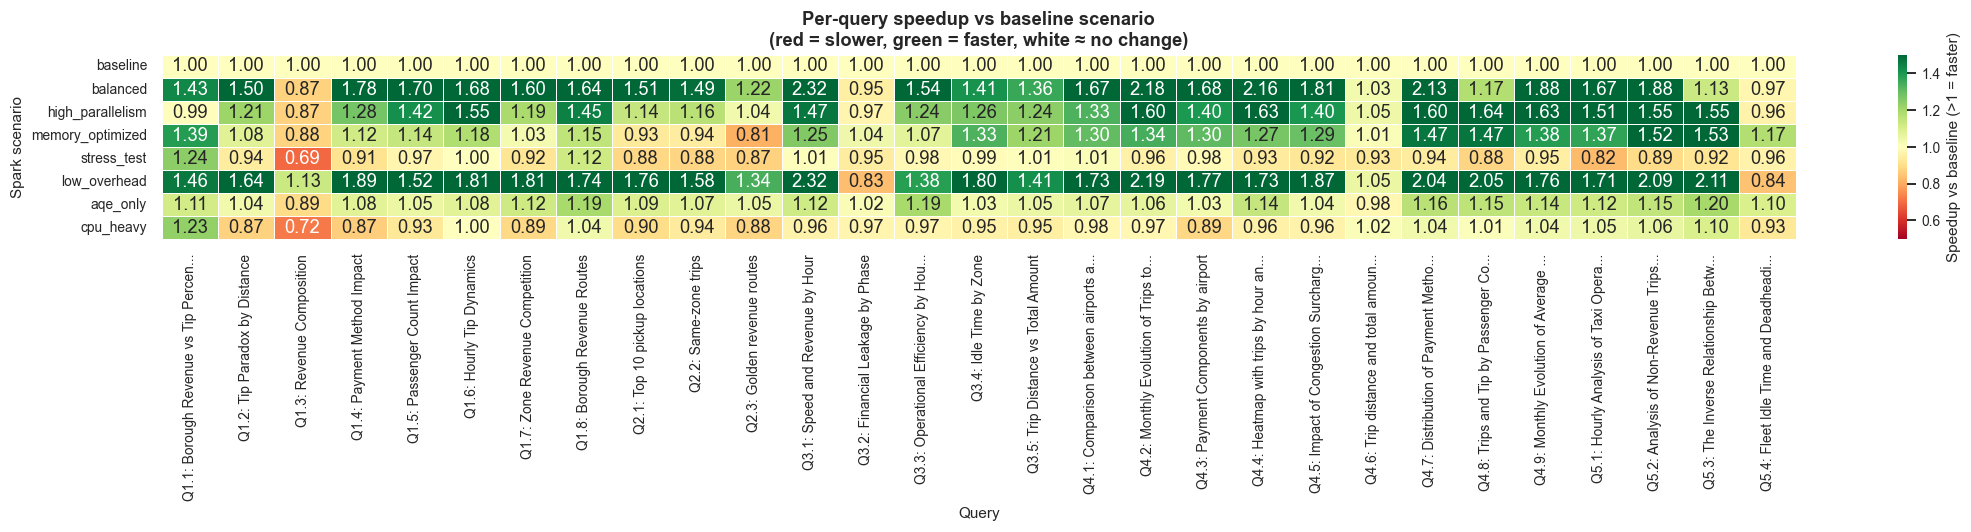


Best cell:  ('balanced', 'Q3.1: Speed and Revenue by Hour') → 2.32× faster than baseline
Worst cell: ('stress_test', 'Q1.3: Revenue Composition') → 0.69× faster than baseline


In [62]:
# Pivot: scenarios as rows, queries as columns, values are mean times
heatmap_data = (
    df_queries.groupby(["spark_mode", "query_description"])["api_time_s"]
              .mean()
              .unstack()
              .reindex(present_scenarios)
)

# Compute speedup ratio over baseline (for each query)
if "baseline" in heatmap_data.index:
    baseline_times = heatmap_data.loc["baseline"]
    speedup = heatmap_data.div(baseline_times, axis=1).rdiv(1.0)  # baseline / scenario
    # Truncate column names
    speedup.columns = [truncate(c, 35) for c in speedup.columns]

    fig, ax = plt.subplots(figsize=(max(10, 0.7 * len(speedup.columns)), 5))
    sns.heatmap(speedup, annot=True, fmt=".2f", center=1.0, cmap="RdYlGn",
                cbar_kws={"label": "Speedup vs baseline (>1 = faster)"},
                linewidths=0.5, linecolor="white", ax=ax, vmin=0.5, vmax=1.5)
    ax.set_title("Per-query speedup vs baseline scenario\n(red = slower, green = faster, white ≈ no change)")
    ax.set_xlabel("Query"); ax.set_ylabel("Spark scenario")
    plt.tight_layout(); plt.show()

    # Find the biggest wins and losses
    flat = speedup.stack()
    print(f"\nBest cell:  {flat.idxmax()} → {flat.max():.2f}× faster than baseline")
    print(f"Worst cell: {flat.idxmin()} → {flat.min():.2f}× faster than baseline")


## **2.5. Variability — how reproducible are the results?**

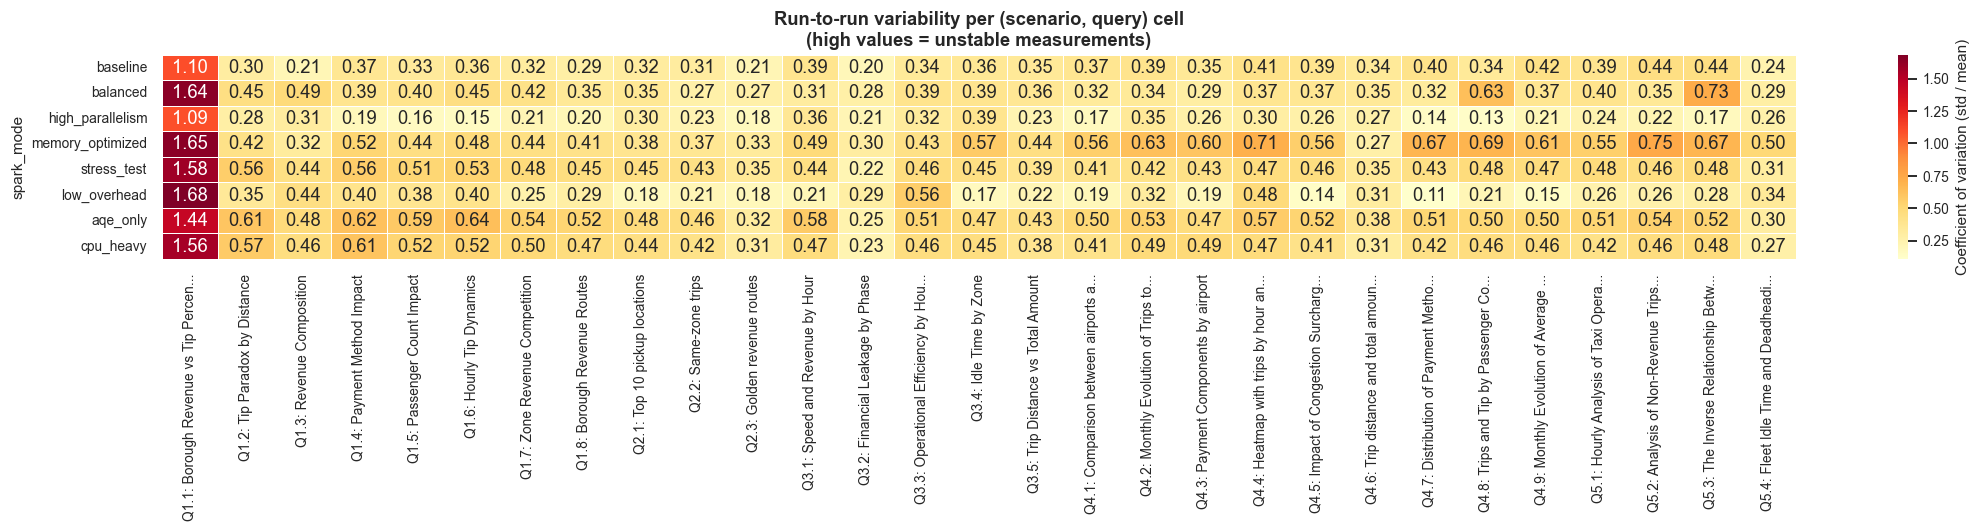


Mean coefficient of variation across all cells: 0.427
→ Measurements are noisy (>25% relative spread); interpret single-run differences with caution.


In [64]:
# Need multiple observations per cell to measure variability
cv = (df_queries.groupby(["spark_mode", "query_description"])["api_time_s"]
                .agg(["mean", "std", "count"]))
cv["cv"] = cv["std"] / cv["mean"]
cv_pivot = (cv["cv"].unstack().reindex(present_scenarios))

# If we have no replicates, std will be NaN — only plot cells with ≥2 observations
if cv_pivot.notna().any().any():
    cv_pivot_display = cv_pivot.copy()
    cv_pivot_display.columns = [truncate(c, 35) for c in cv_pivot_display.columns]

    fig, ax = plt.subplots(figsize=(max(10, 0.7 * len(cv_pivot_display.columns)), 5))
    sns.heatmap(cv_pivot_display, annot=True, fmt=".2f", cmap="YlOrRd",
                cbar_kws={"label": "Coefficient of variation (std / mean)"},
                linewidths=0.5, linecolor="white", ax=ax)
    ax.set_title("Run-to-run variability per (scenario, query) cell\n(high values = unstable measurements)")
    plt.tight_layout(); plt.show()

    mean_cv = cv["cv"].mean()
    print(f"\nMean coefficient of variation across all cells: {mean_cv:.3f}")
    if mean_cv < 0.1:
        print("→ Measurements are stable (<10% relative spread).")
    elif mean_cv < 0.25:
        print("→ Measurements show moderate noise (10–25% relative spread).")
    else:
        print("→ Measurements are noisy (>25% relative spread); interpret single-run differences with caution.")
else:
    print("Not enough replicate observations to compute variability. "
          "Each (scenario, query) cell has only 1 data point.")


---

# **3. Scaling Analysis — Speedup, Efficiency, Amdahl's Law**

Our scenarios vary in `total_cores = executor_instances × executor_cores`, from 2 to 8 cores. We use the `baseline` scenario as the reference point.

**Definitions:**
- **Speedup**: S(p) = T(baseline) / T(p)
- **Parallel efficiency**: E(p) = S(p) / (p / p_baseline) — how close to ideal linear speedup
- **Implied serial fraction** from Amdahl's Law: f = (1/S − 1/p) / (1 − 1/p)

## **3.1. Strong scaling curve**

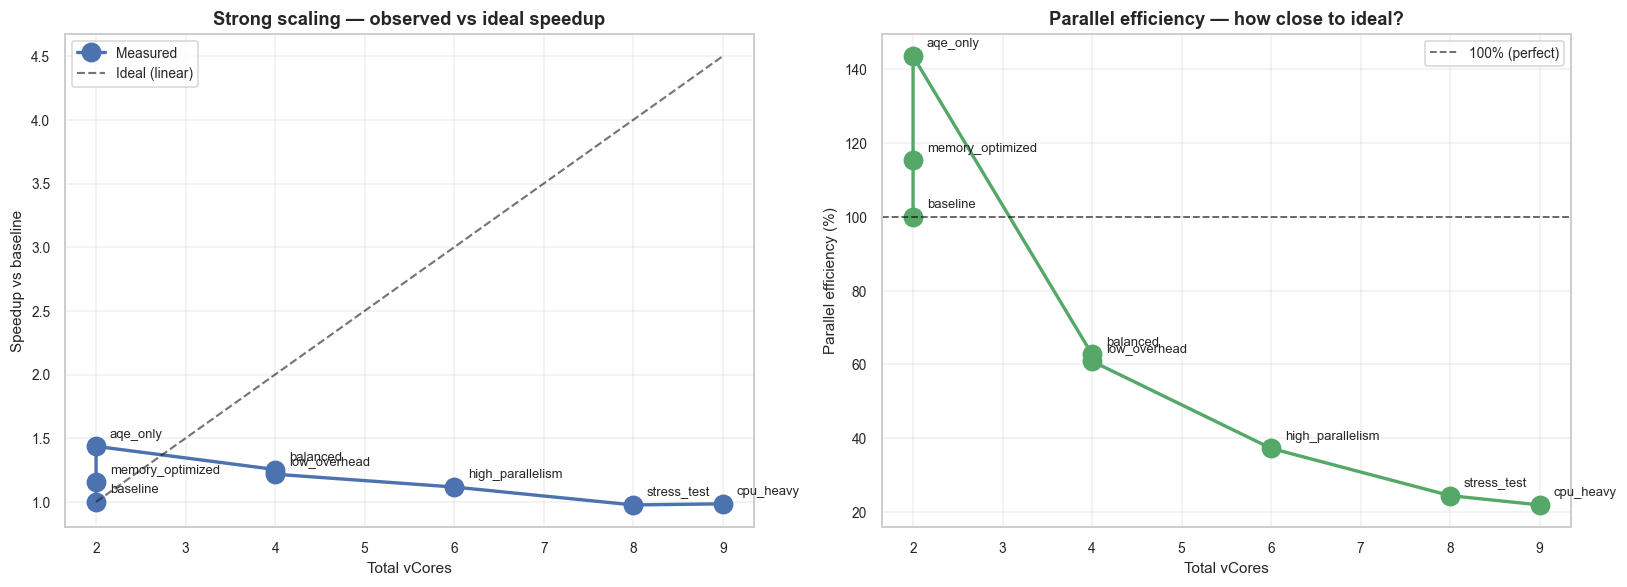


Scaling summary:
      spark_mode  total_cores  mean_time  speedup  efficiency
        baseline            2   1089.820    1.000       1.000
memory_optimized            2    944.933    1.153       1.153
        aqe_only            2    759.010    1.436       1.436
        balanced            4    869.051    1.254       0.627
    low_overhead            4    895.412    1.217       0.609
high_parallelism            6    976.183    1.116       0.372
     stress_test            8   1116.945    0.976       0.244
       cpu_heavy            9   1107.010    0.984       0.219


In [65]:
# Total time per scenario, using API as canonical
scaling = (
    df_queries.groupby("spark_mode")
              .agg(mean_time=("api_time_s", "sum"),
                   total_cores=("total_cores", "first"))
              .reindex(present_scenarios)
              .reset_index()
              .sort_values("total_cores")
)

# Reference: baseline
T_base = scaling.loc[scaling["spark_mode"] == "baseline", "mean_time"].iloc[0]
p_base = scaling.loc[scaling["spark_mode"] == "baseline", "total_cores"].iloc[0]
scaling["speedup"] = T_base / scaling["mean_time"]
scaling["efficiency"] = scaling["speedup"] / (scaling["total_cores"] / p_base)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# (a) Speedup curve
axes[0].plot(scaling["total_cores"], scaling["speedup"], "o-",
             color="#4C72B0", markersize=12, lw=2.2, label="Measured")
cr = np.linspace(scaling["total_cores"].min(), scaling["total_cores"].max(), 50)
axes[0].plot(cr, cr / p_base, "k--", lw=1.4, label="Ideal (linear)", alpha=0.6)
for _, r in scaling.iterrows():
    axes[0].annotate(r["spark_mode"], (r["total_cores"], r["speedup"]),
                     xytext=(9, 6), textcoords="offset points", fontsize=8.5)
axes[0].set_xlabel("Total vCores"); axes[0].set_ylabel("Speedup vs baseline")
axes[0].set_title("Strong scaling — observed vs ideal speedup")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# (b) Parallel efficiency
axes[1].plot(scaling["total_cores"], scaling["efficiency"] * 100, "o-",
             color="#55A868", markersize=12, lw=2.2)
axes[1].axhline(100, color="black", linestyle="--", lw=1.2, alpha=0.6, label="100% (perfect)")
for _, r in scaling.iterrows():
    axes[1].annotate(r["spark_mode"], (r["total_cores"], r["efficiency"] * 100),
                     xytext=(9, 6), textcoords="offset points", fontsize=8.5)
axes[1].set_xlabel("Total vCores"); axes[1].set_ylabel("Parallel efficiency (%)")
axes[1].set_title("Parallel efficiency — how close to ideal?")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print("\nScaling summary:")
print(scaling[["spark_mode", "total_cores", "mean_time", "speedup", "efficiency"]].round(3).to_string(index=False))


## **3.3. Decoupling cores from other config dimensions**

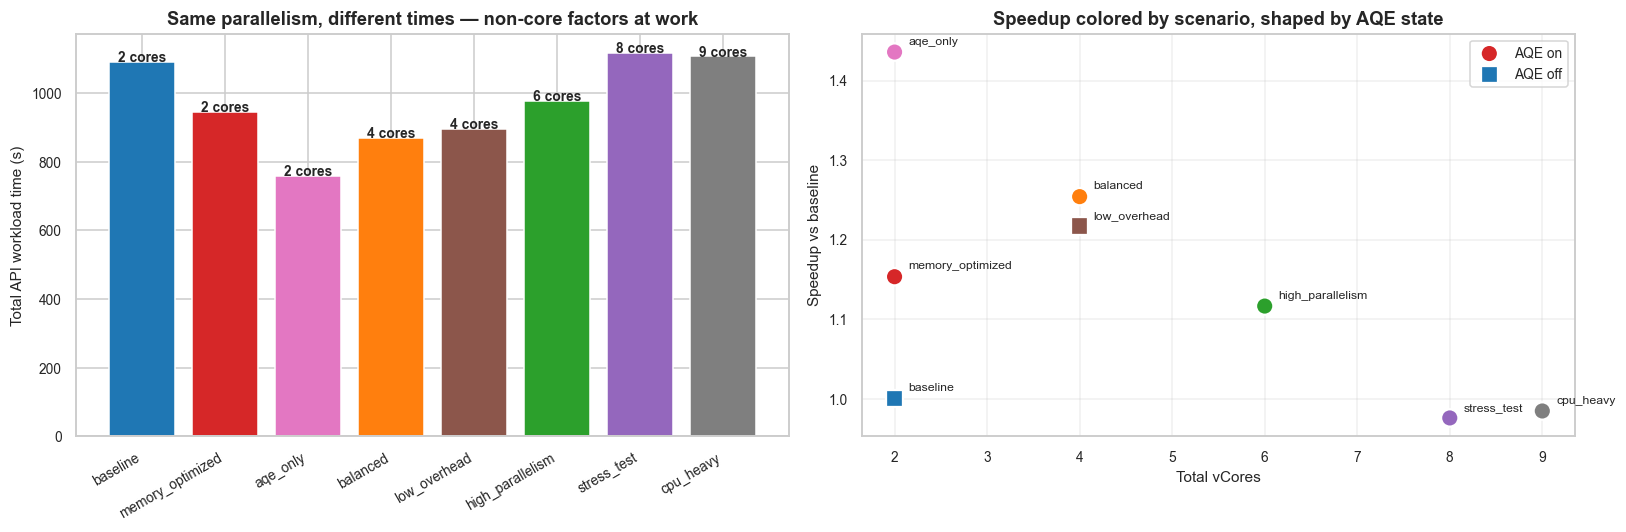

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# (a) Time grouped by total_cores
sc_sorted = scaling.sort_values("total_cores")
colors = [SCENARIO_PALETTE[s] for s in sc_sorted["spark_mode"]]
bars = axes[0].bar(sc_sorted["spark_mode"], sc_sorted["mean_time"],
                   color=colors, edgecolor="white")
for bar, cores in zip(bars, sc_sorted["total_cores"]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{int(cores)} cores", ha="center", fontsize=9, fontweight="bold")
axes[0].set_xticklabels(sc_sorted["spark_mode"], rotation=30, ha="right")
axes[0].set_ylabel("Total API workload time (s)")
axes[0].set_title("Same parallelism, different times — non-core factors at work")

# (b) Speedup vs total_cores colored by AQE
aqe_marker = scaling.merge(scenario_cfg[["adaptive"]], left_on="spark_mode", right_index=True)
for adapt_val, marker, lbl in [(True, "o", "AQE on"), (False, "s", "AQE off")]:
    sub = aqe_marker[aqe_marker["adaptive"] == adapt_val]
    axes[1].scatter(sub["total_cores"], sub["speedup"],
                    marker=marker, s=130, label=lbl,
                    c=[SCENARIO_PALETTE[s] for s in sub["spark_mode"]],
                    edgecolor="white", linewidth=1.5)
    for _, r in sub.iterrows():
        axes[1].annotate(r["spark_mode"], (r["total_cores"], r["speedup"]),
                         xytext=(9, 5), textcoords="offset points", fontsize=8)
axes[1].set_xlabel("Total vCores"); axes[1].set_ylabel("Speedup vs baseline")
axes[1].set_title("Speedup colored by scenario, shaped by AQE state")
axes[1].grid(True, alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()


## **3.4. Correlation between configuration features and performance**

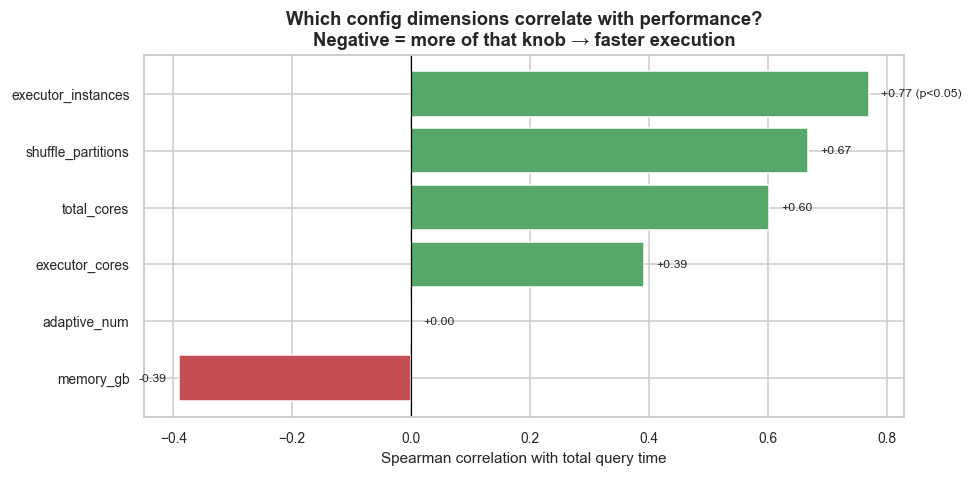


Full table:
         dimension    rho  p_value
         memory_gb -0.391    0.338
      adaptive_num  0.000    1.000
    executor_cores  0.391    0.338
       total_cores  0.602    0.115
shuffle_partitions  0.667    0.071
executor_instances  0.770    0.025


In [68]:
from scipy.stats import spearmanr

corr_data = scenario_cfg.merge(totals[["api_total"]], left_index=True, right_index=True)
corr_data["adaptive_num"] = corr_data["adaptive"].astype(int)
corr_data["memory_gb"] = corr_data["executor_memory"].str.replace("g", "", regex=False).astype(float)

config_dims = ["executor_instances", "executor_cores", "memory_gb",
               "shuffle_partitions", "adaptive_num", "total_cores"]

correlations = []
for dim in config_dims:
    rho, pval = spearmanr(corr_data[dim], corr_data["api_total"])
    correlations.append({"dimension": dim, "rho": rho, "p_value": pval})
corr_df = pd.DataFrame(correlations).sort_values("rho")

fig, ax = plt.subplots(figsize=(9, 4.5))
colors_corr = ["#C44E52" if r < 0 else "#55A868" for r in corr_df["rho"]]
ax.barh(corr_df["dimension"], corr_df["rho"], color=colors_corr, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Spearman correlation with total query time")
ax.set_title("Which config dimensions correlate with performance?\n"
             "Negative = more of that knob → faster execution")
for i, (rho, p) in enumerate(zip(corr_df["rho"], corr_df["p_value"])):
    sig = " (p<0.05)" if p < 0.05 else ""
    ax.text(rho + (0.02 if rho >= 0 else -0.02), i,
            f"{rho:+.2f}{sig}", va="center",
            ha="left" if rho >= 0 else "right", fontsize=8)
plt.tight_layout(); plt.show()
print("\nFull table:")
print(corr_df.round(3).to_string(index=False))


---

# **4. Spark Performance — ML Models**

## **4.1. Training time per (model × scenario)**

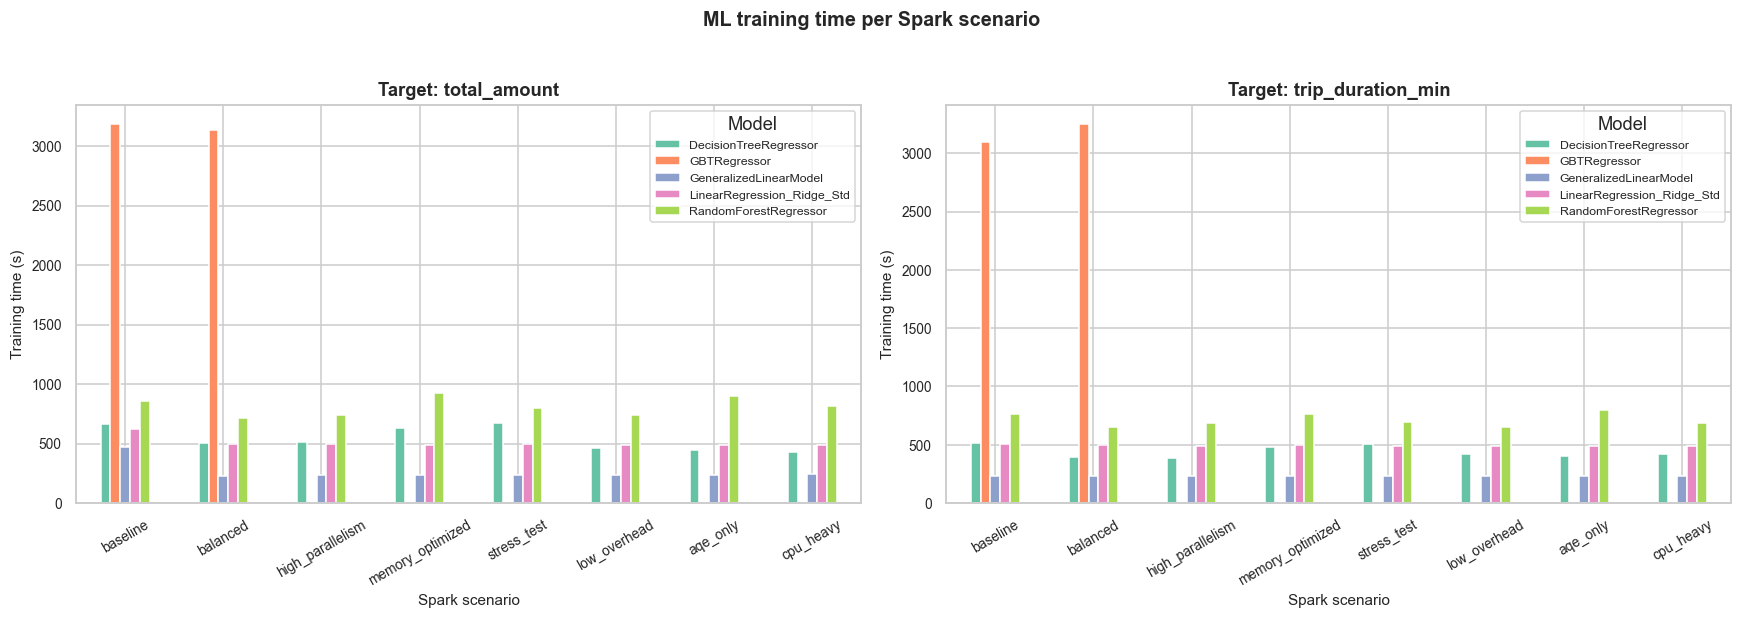

In [69]:
ml_times = (
    df_models.groupby(["model_name", "target", "spark_mode"])
             .agg(mean_time=("execution_time_seconds", "mean"),
                  std_time=("execution_time_seconds", "std"))
             .reset_index()
)

targets = sorted(df_models["target"].dropna().unique())
fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5.5))
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = ml_times[ml_times["target"] == target]
    pivot = (sub.pivot(index="spark_mode", columns="model_name", values="mean_time")
                .reindex([s for s in present_scenarios_models if s in sub["spark_mode"].unique()]))
    pivot.plot(kind="bar", ax=ax, edgecolor="white",
               color=[MODEL_PALETTE.get(m, "#888") for m in pivot.columns])
    ax.set_title(f"Target: {target}")
    ax.set_xlabel("Spark scenario"); ax.set_ylabel("Training time (s)")
    ax.tick_params(axis="x", rotation=30)
    ax.legend(title="Model", fontsize=8, loc="best")

plt.suptitle("ML training time per Spark scenario", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()


## **4.2. ML scaling — how does each model respond to more cores?**

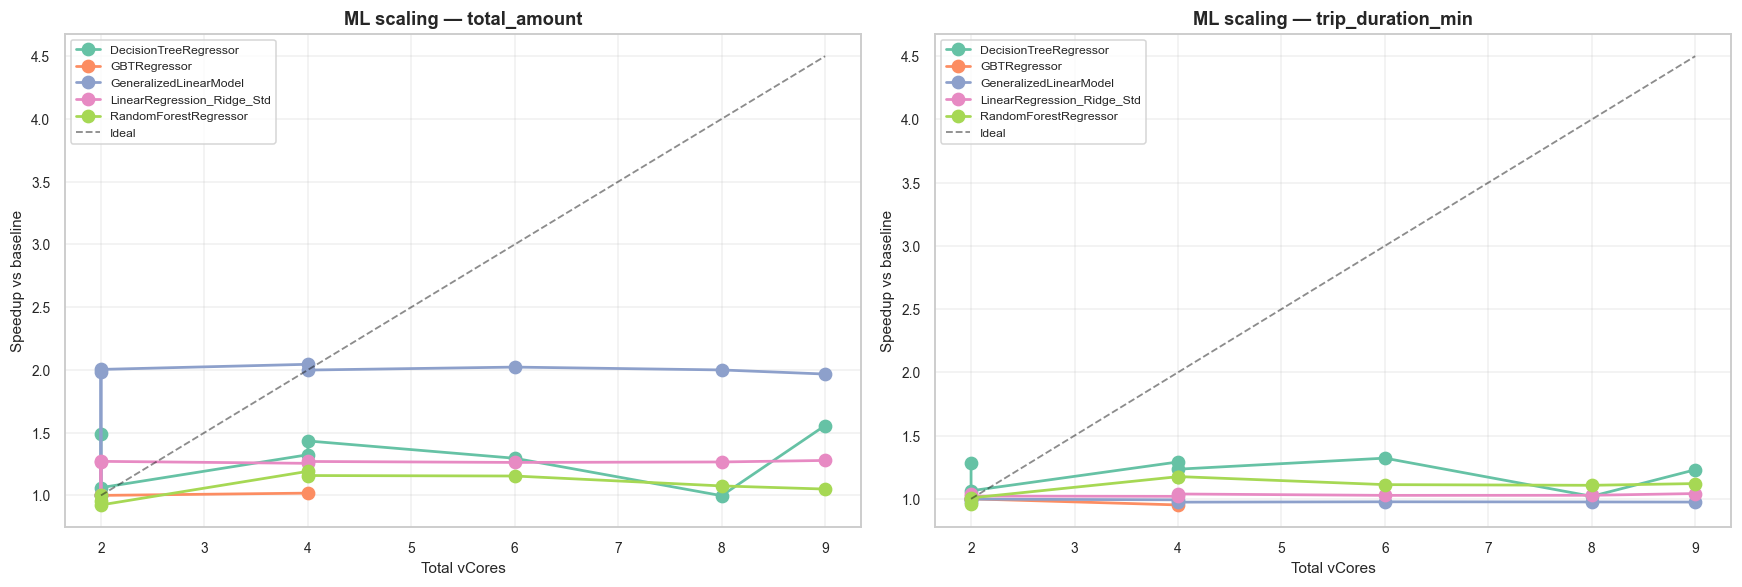

In [70]:
# Compute speedup vs baseline for each model
ml_scaling = (
    df_models.groupby(["model_name", "target", "spark_mode", "total_cores"])
             .agg(time=("execution_time_seconds", "mean"))
             .reset_index()
)

fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5.5))
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = ml_scaling[ml_scaling["target"] == target]
    for model in sorted(sub["model_name"].unique()):
        ms = sub[sub["model_name"] == model].sort_values("total_cores")
        if (ms["spark_mode"] == "baseline").any():
            t_b = ms.loc[ms["spark_mode"] == "baseline", "time"].iloc[0]
            p_b = ms.loc[ms["spark_mode"] == "baseline", "total_cores"].iloc[0]
            ms = ms.assign(speedup=t_b / ms["time"])
            ax.plot(ms["total_cores"], ms["speedup"], "o-",
                    label=model, color=MODEL_PALETTE.get(model, "#888"),
                    markersize=8, lw=1.8)
    # Ideal line
    cr = np.linspace(ms["total_cores"].min(), ms["total_cores"].max(), 30)
    ax.plot(cr, cr / p_b, "k--", lw=1.2, alpha=0.5, label="Ideal")
    ax.set_xlabel("Total vCores"); ax.set_ylabel("Speedup vs baseline")
    ax.set_title(f"ML scaling — {target}")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## **4.3. Cost vs accuracy trade-off**

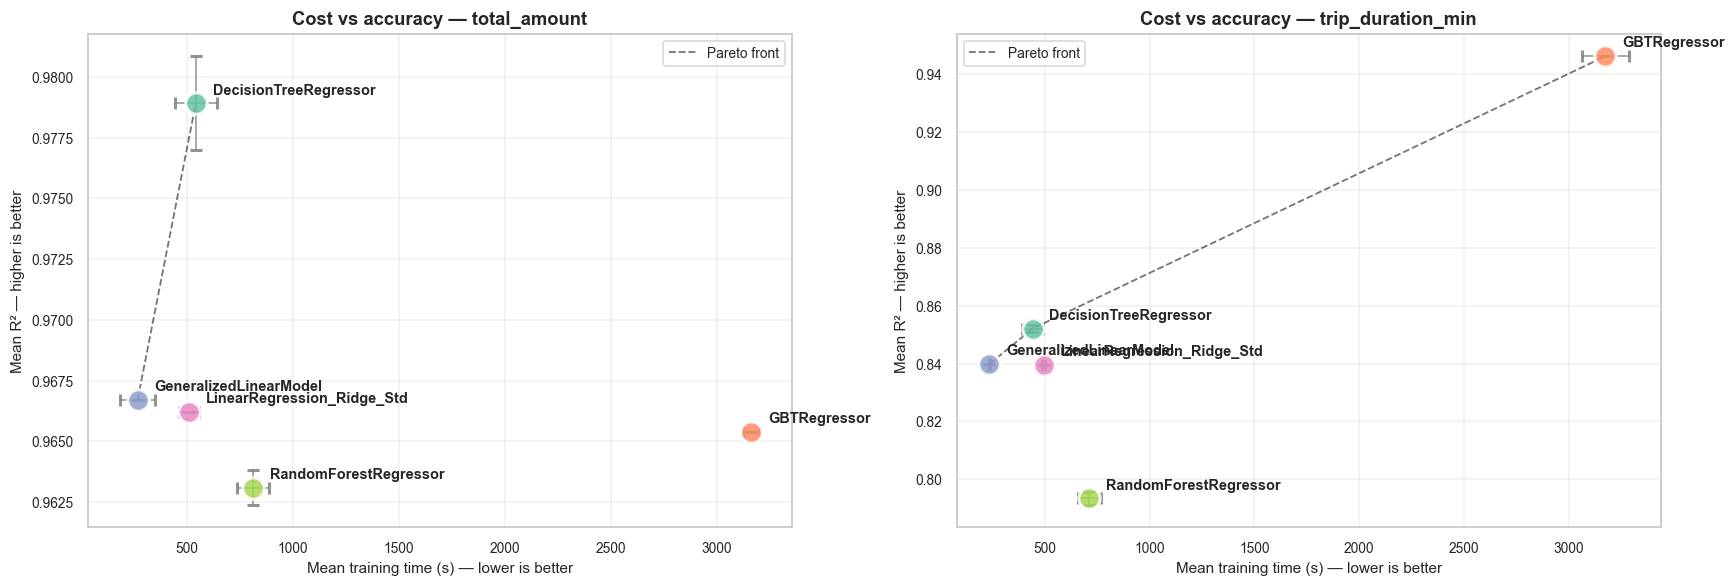

In [71]:
tradeoff = (
    df_models.groupby(["model_name", "target"])
             .agg(mean_time=("execution_time_seconds", "mean"),
                  mean_r2=("r2", "mean"),
                  mean_rmse=("rmse", "mean"),
                  std_time=("execution_time_seconds", "std"),
                  std_r2=("r2", "std"))
             .reset_index()
)

fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5.5))
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = tradeoff[tradeoff["target"] == target]
    for _, r in sub.iterrows():
        ax.errorbar(r["mean_time"], r["mean_r2"],
                    xerr=r["std_time"], yerr=r["std_r2"],
                    fmt="o", markersize=14,
                    color=MODEL_PALETTE.get(r["model_name"], "#888"),
                    ecolor="gray", elinewidth=1, capsize=4, alpha=0.85,
                    markeredgecolor="white", markeredgewidth=2)
        ax.annotate(r["model_name"], (r["mean_time"], r["mean_r2"]),
                    xytext=(11, 6), textcoords="offset points", fontsize=9.5, fontweight="bold")
    # Pareto front
    ss = sub.sort_values("mean_time")
    pareto = []
    best = -np.inf
    for _, r in ss.iterrows():
        if r["mean_r2"] > best:
            pareto.append((r["mean_time"], r["mean_r2"]))
            best = r["mean_r2"]
    if len(pareto) > 1:
        px, py = zip(*pareto)
        ax.plot(px, py, "k--", lw=1.2, alpha=0.6, label="Pareto front")
        ax.legend()
    ax.set_xlabel("Mean training time (s) — lower is better")
    ax.set_ylabel("Mean R² — higher is better")
    ax.set_title(f"Cost vs accuracy — {target}")
    ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


## **4.4. Training time variability per model**

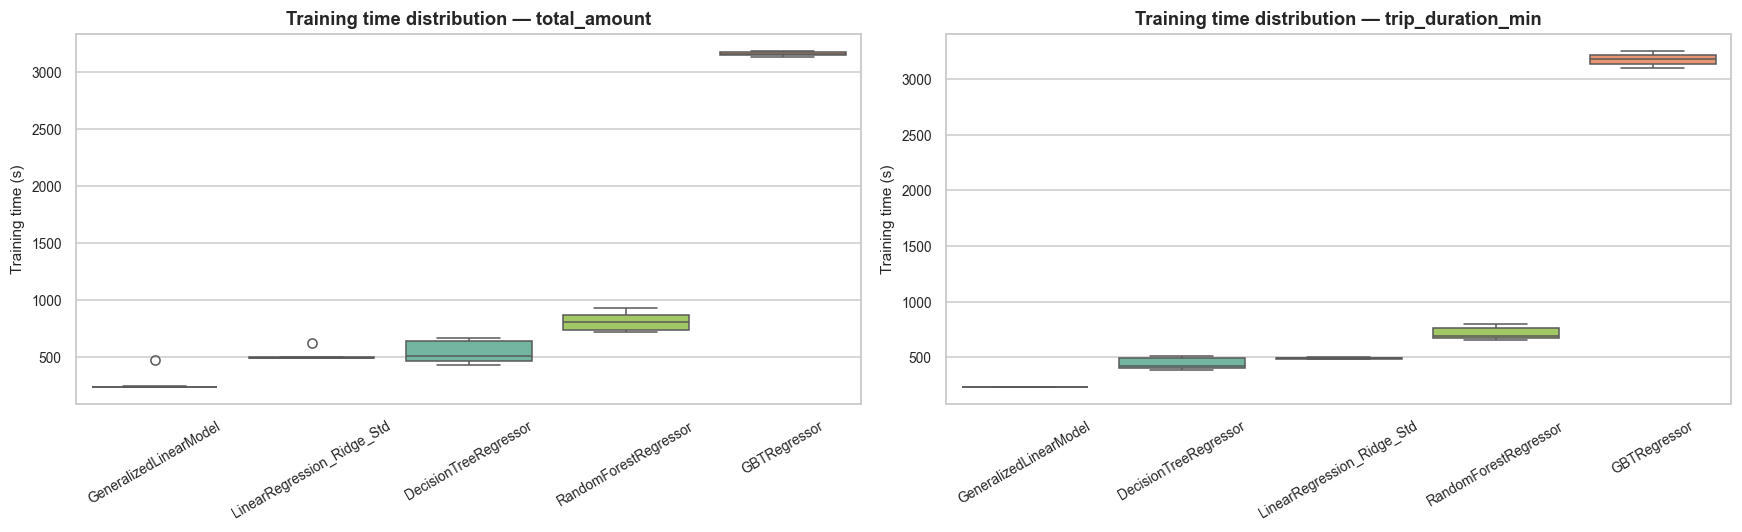

In [72]:
fig, axes = plt.subplots(1, len(targets), figsize=(8 * len(targets), 5))
if len(targets) == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = df_models[df_models["target"] == target]
    model_order = (sub.groupby("model_name")["execution_time_seconds"]
                      .median().sort_values().index.tolist())
    sns.boxplot(data=sub, x="model_name", y="execution_time_seconds",
                order=model_order,
                palette=[MODEL_PALETTE.get(m, "#888") for m in model_order],
                ax=ax)
    ax.set_title(f"Training time distribution — {target}")
    ax.set_xlabel(""); ax.set_ylabel("Training time (s)")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout(); plt.show()


---

# **5. ML Model Comparison — Quality of Predictions**

## **5.1. Leaderboard per target**

In [73]:
for target in targets:
    print(f"\n{'='*65}\n  TARGET: {target}\n{'='*65}")
    lb = (df_models[df_models["target"] == target]
              .groupby("model_name")
              .agg(best_rmse=("rmse", "min"),
                   best_r2=("r2", "max"),
                   best_mae=("mae", "min"),
                   mean_time_s=("execution_time_seconds", "mean"))
              .sort_values("best_r2", ascending=False)
              .round(4))
    print(lb)



  TARGET: total_amount
                            best_rmse  best_r2  best_mae  mean_time_s
model_name                                                           
DecisionTreeRegressor          1.6910   0.9816    0.5982     541.2125
GeneralizedLinearModel         2.2707   0.9667    1.2043     266.3775
LinearRegression_Ridge_Std     2.2880   0.9662    1.2109     508.7200
GBTRegressor                   2.3165   0.9654    1.1289    3161.0050
RandomForestRegressor          2.3599   0.9641    1.2600     810.6688

  TARGET: trip_duration_min
                            best_rmse  best_r2  best_mae  mean_time_s
model_name                                                           
GBTRegressor                   2.3297   0.9462    1.0728    3176.1700
DecisionTreeRegressor          3.8562   0.8531    1.4068     440.9838
GeneralizedLinearModel         4.0182   0.8398    2.3412     233.5662
LinearRegression_Ridge_Std     4.0208   0.8396    2.3487     493.5675
RandomForestRegressor          4.5280

## **5.2. Side-by-side metric comparison**

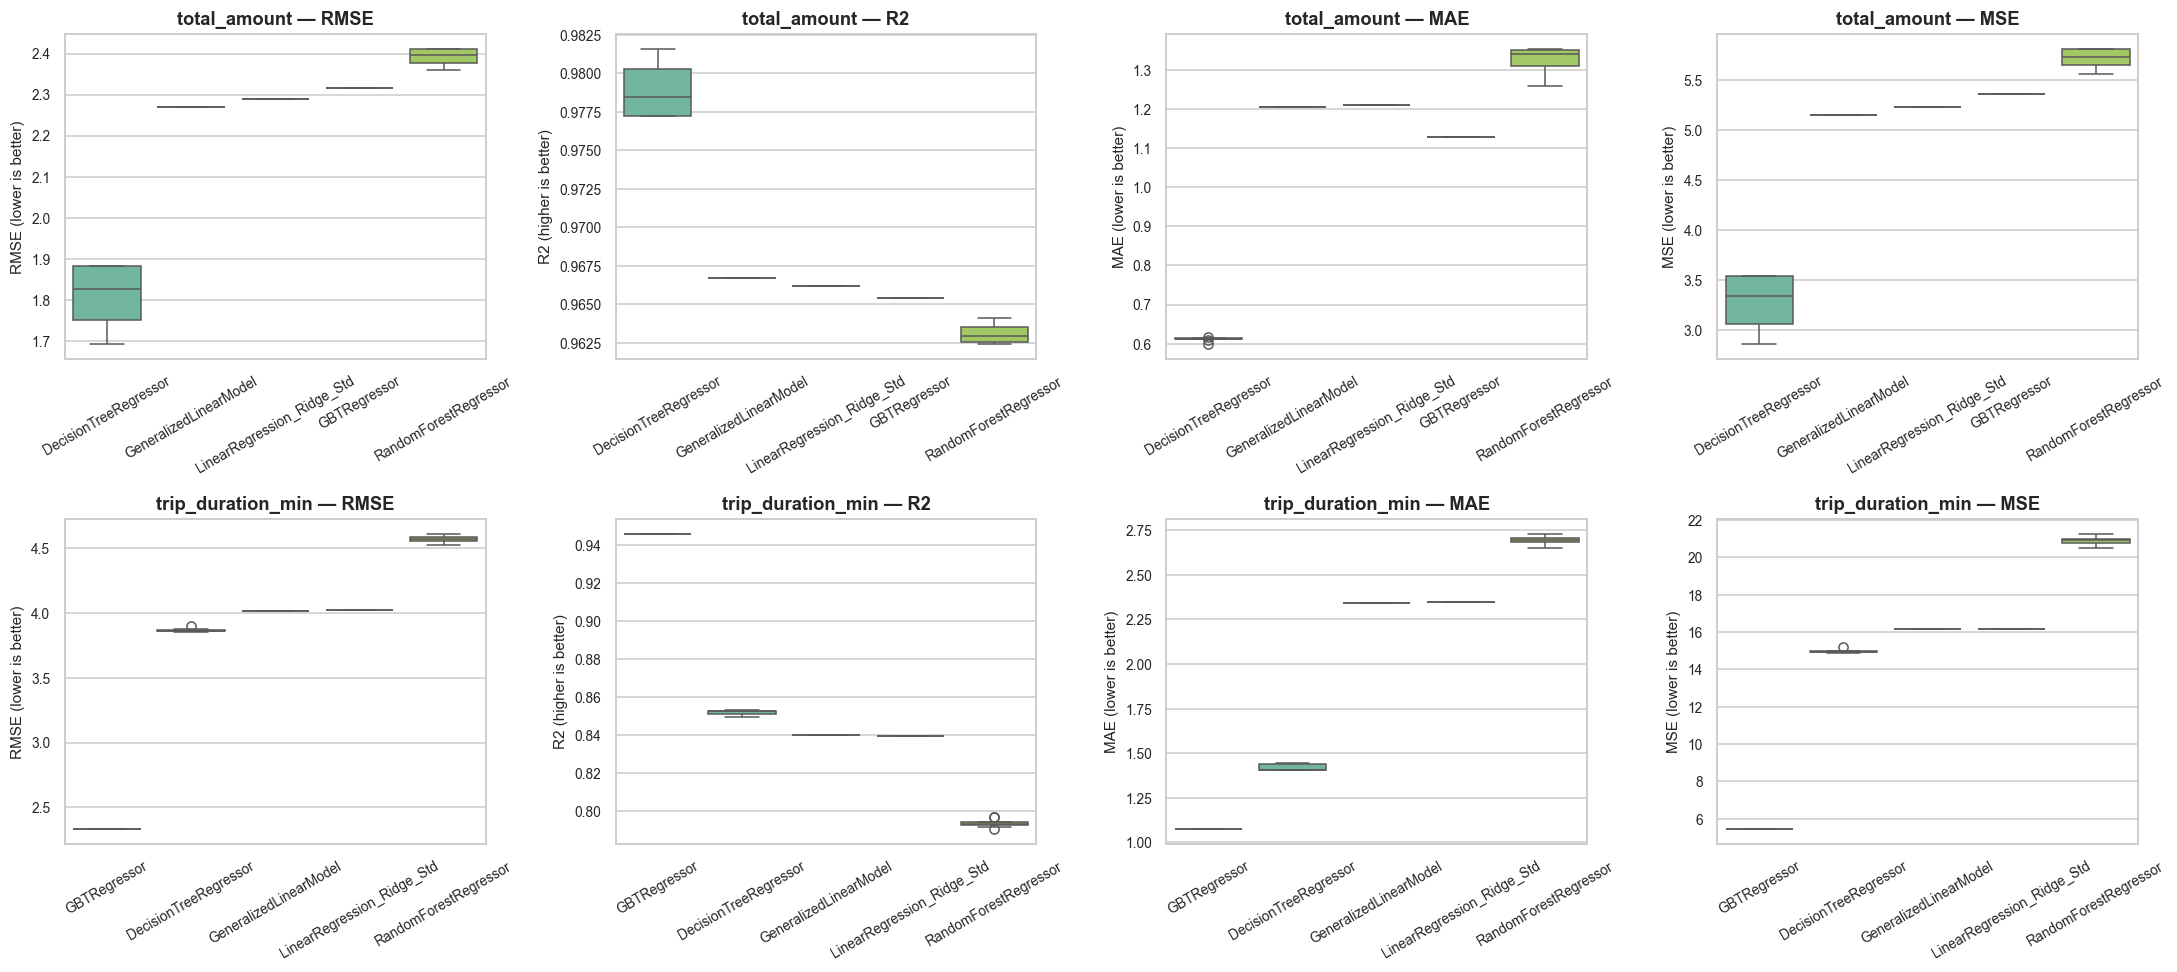

In [74]:
metrics_to_plot = ["rmse", "r2", "mae", "mse"]
n_t = len(targets)
fig, axes = plt.subplots(n_t, 4, figsize=(20, 4.5 * n_t))
if n_t == 1:
    axes = axes.reshape(1, -1)

for row, target in enumerate(targets):
    sub = df_models[df_models["target"] == target]
    model_order = (sub.groupby("model_name")["r2"].mean()
                      .sort_values(ascending=False).index.tolist())
    for col, metric in enumerate(metrics_to_plot):
        ax = axes[row, col]
        sns.boxplot(data=sub, x="model_name", y=metric, order=model_order,
                    palette=[MODEL_PALETTE.get(m, "#888") for m in model_order],
                    ax=ax)
        ax.set_title(f"{target} — {metric.upper()}")
        ax.set_xlabel(""); ax.tick_params(axis="x", rotation=30)
        ax.set_ylabel(f"{metric.upper()} " +
                      ("(higher is better)" if metric == "r2" else "(lower is better)"))
plt.tight_layout(); plt.show()


## **5.3. Model stability across Spark scenarios**

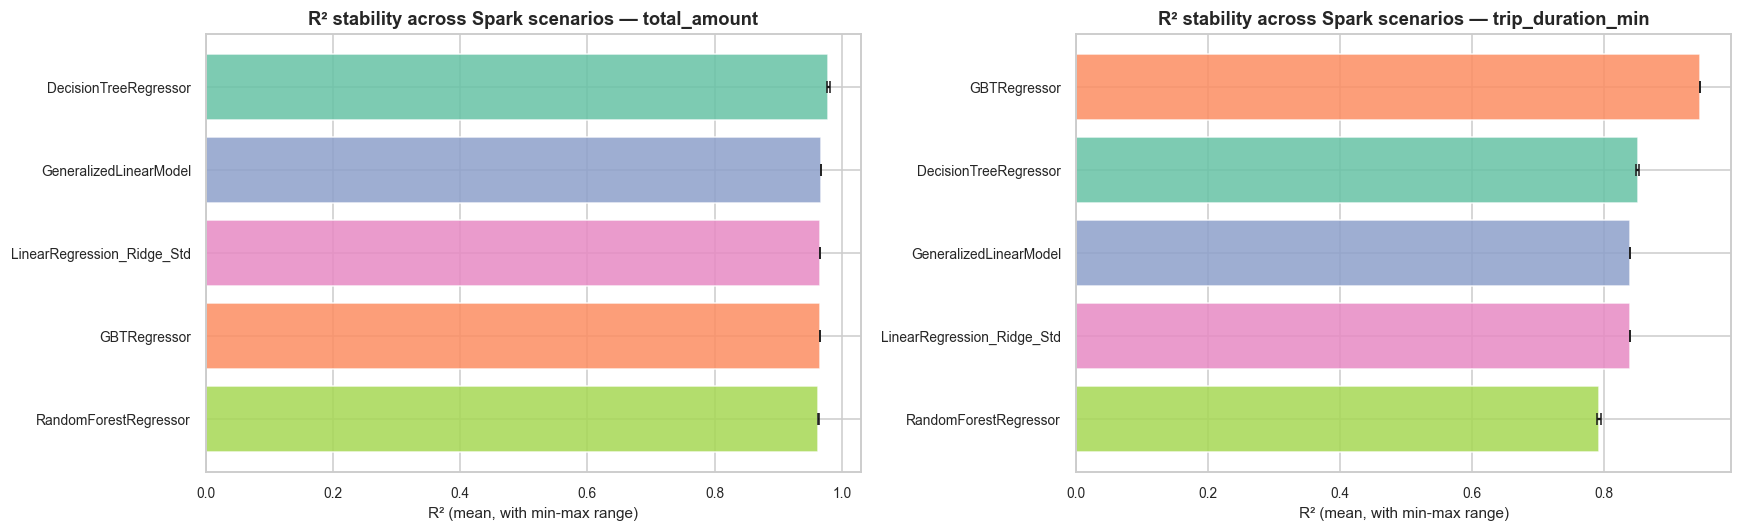


R² coefficient of variation per model (lower = more stable):

  total_amount:
    GBTRegressor                         CV = 0.0000
    GeneralizedLinearModel               CV = 0.0000
    LinearRegression_Ridge_Std           CV = 0.0000
    RandomForestRegressor                CV = 0.0007
    DecisionTreeRegressor                CV = 0.0020

  trip_duration_min:
    GBTRegressor                         CV = 0.0000
    GeneralizedLinearModel               CV = 0.0000
    LinearRegression_Ridge_Std           CV = 0.0000
    DecisionTreeRegressor                CV = 0.0015
    RandomForestRegressor                CV = 0.0029


In [75]:
fig, axes = plt.subplots(1, n_t, figsize=(8 * n_t, 5))
if n_t == 1:
    axes = [axes]

for ax, target in zip(axes, targets):
    sub = df_models[df_models["target"] == target]
    stability = (sub.groupby("model_name")["r2"]
                    .agg(["mean", "std", "min", "max"])
                    .sort_values("mean", ascending=False))
    y = np.arange(len(stability))
    ax.barh(y, stability["mean"],
            xerr=[stability["mean"] - stability["min"],
                  stability["max"] - stability["mean"]],
            color=[MODEL_PALETTE.get(m, "#888") for m in stability.index],
            edgecolor="white", capsize=4, alpha=0.85)
    ax.set_yticks(y); ax.set_yticklabels(stability.index)
    ax.set_xlabel("R² (mean, with min-max range)")
    ax.set_title(f"R² stability across Spark scenarios — {target}")
    ax.invert_yaxis()

plt.tight_layout(); plt.show()

print("\nR² coefficient of variation per model (lower = more stable):")
for target in targets:
    sub = df_models[df_models["target"] == target]
    cv_r2 = sub.groupby("model_name")["r2"].agg(lambda s: s.std() / abs(s.mean())).sort_values()
    print(f"\n  {target}:")
    for m, v in cv_r2.items():
        print(f"    {m:35s}  CV = {v:.4f}")


## **5.4. Joint metric view — radar chart**

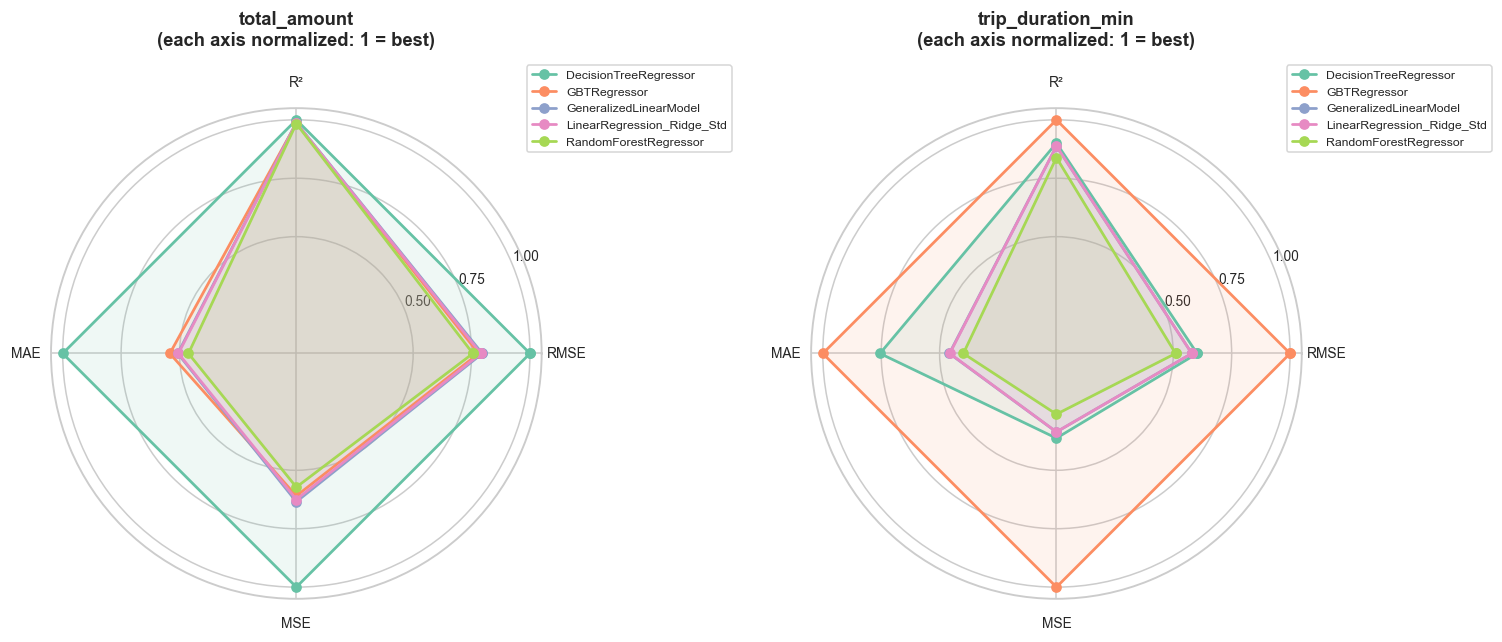

In [76]:
# Normalize each metric so 1 = best (across the models for that target)
def make_radar_data(df, target):
    sub = (df[df["target"] == target]
              .groupby("model_name")
              .agg(rmse=("rmse", "mean"), r2=("r2", "mean"),
                   mae=("mae", "mean"), mse=("mse", "mean"))
              .copy())
    # For 'lower is better' metrics, invert: norm = best_value / value
    for col in ["rmse", "mae", "mse"]:
        sub[col + "_norm"] = sub[col].min() / sub[col]
    # For R², norm = value / best
    sub["r2_norm"] = sub["r2"] / sub["r2"].max()
    return sub

fig, axes = plt.subplots(1, n_t, figsize=(7 * n_t, 6),
                         subplot_kw=dict(projection="polar"))
if n_t == 1:
    axes = [axes]

axis_labels = ["RMSE", "R²", "MAE", "MSE"]
angles = np.linspace(0, 2 * np.pi, len(axis_labels), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

for ax, target in zip(axes, targets):
    radar = make_radar_data(df_models, target)
    norm_cols = ["rmse_norm", "r2_norm", "mae_norm", "mse_norm"]
    for model in radar.index:
        values = radar.loc[model, norm_cols].tolist()
        values += values[:1]
        ax.plot(angles, values, "o-", lw=1.8, label=model,
                color=MODEL_PALETTE.get(model, "#888"))
        ax.fill(angles, values, alpha=0.10,
                color=MODEL_PALETTE.get(model, "#888"))
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(axis_labels)
    ax.set_ylim(0, 1.05); ax.set_yticks([0.5, 0.75, 1.0])
    ax.set_title(f"{target}\n(each axis normalized: 1 = best)", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=8)

plt.tight_layout(); plt.show()
